## student performance indicator

### life cycle of machine learning project

1. understanding the problem statement
2. data collection
3. data checks to perform
4. exploratory data analysis
5. data preprocessing
6. model training
7. choose best model

### 1. problem statement
This project understands how the student's performance test scores are affected by other variables such as:
- gender
- ethnicity
- parental level of education
- lunch
- test preparation course

### 2. data collection 
1. dataset source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
2. the data consists of 8 columns and 1000 rows

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/studentsperformance.csv')

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

### data checks to perform
1. Check missing values.
2. Check duplicates.
3. Check data type.
4. Check the number of unique values of each column.
5. Check statistics of the dataset.
6. Check various categories present in the different categorical columns.

In [5]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

there are no missing values in dataset

In [6]:
df.duplicated().sum()

np.int64(0)

there are no duplcates values in the dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [8]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [9]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### insight
1. From the above description of numerical data, all means are very close to each other, between 66 and 68.05.
2. All standard deviations are also close, between 14.6 and 15.19.
3. While there is a minimum score of 0 for math, the minimum is much higher, equal to 10, and for reading, the minimum is much higher, equal to 17.

In [10]:
print("categories in 'gender' variable: ",end=" ")
print(df['gender'].unique())

print("categories in 'race/ethnicity' variable: ",end=" ")
print(df['race/ethnicity'].unique())

print("categories in 'parental level of education' variable: ",end=" ")
print(df['parental level of education'].unique())

print("categories in 'lunch' variable: ",end=" ")
print(df['lunch'].unique())

print("categories in 'test preparation course' variable: ",end=" ")
print(df['test preparation course'].unique())

categories in 'gender' variable:  ['female' 'male']
categories in 'race/ethnicity' variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
categories in 'parental level of education' variable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
categories in 'lunch' variable:  ['standard' 'free/reduced']
categories in 'test preparation course' variable:  ['none' 'completed']


In [14]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

#print columns
print('we have {} numerical features: {}'.format(len(numeric_features),numeric_features))
print('we have {} categorical features {} : '.format(len(categorical_features),categorical_features))

we have 3 numerical features: ['math score', 'reading score', 'writing score']
we have 5 categorical features ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course'] : 


In [15]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [16]:
reading_full = df[df['reading score']== 100]['average'].count()
writing_full = df[df['writing score']==100]['average'].count()
math_full = df[df['math score']==100]['average'].count()

print(f'number of students with full marks in maths: {math_full}')
print(f'number of students with full marks in writing: {writing_full}')
print(f'number of students with full marks in reading: {reading_full}')


number of students with full marks in maths: 7
number of students with full marks in writing: 14
number of students with full marks in reading: 17


In [17]:
reading_less_20 = df[df['reading score']<=20]['average'].count()
writing_less_20 = df[df['writing score']<=20]['average'].count()
math_less_20 = df[df['math score']<=20]['average'].count()

print('number of students with less than 20 marks in maths: ',math_less_20)
print('number of students with less than 20 marks in writing: ',writing_less_20)
print('number of students with less than 20 marks in reading: ',reading_less_20)

number of students with less than 20 marks in maths:  4
number of students with less than 20 marks in writing:  3
number of students with less than 20 marks in reading:  1


### insights
1. from above values we get student have performed worst in maths
2. best performance is in reading section

### Visualize average score distribution to make some conclusion.
1.  histogram 
2. kernel distribution function(KDE)

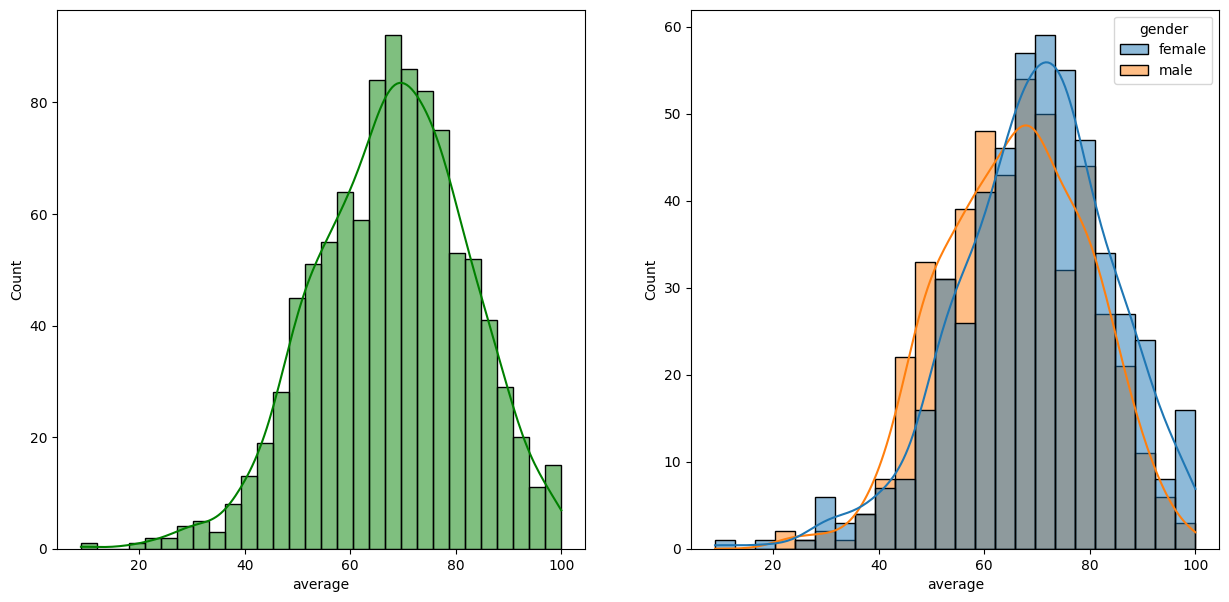

In [19]:
fig,axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='gender')
plt.show()

### insights
1. female students tend to perform well than male students

ValueError: Could not interpret value `average,` for `x`. An entry with this name does not appear in `data`.

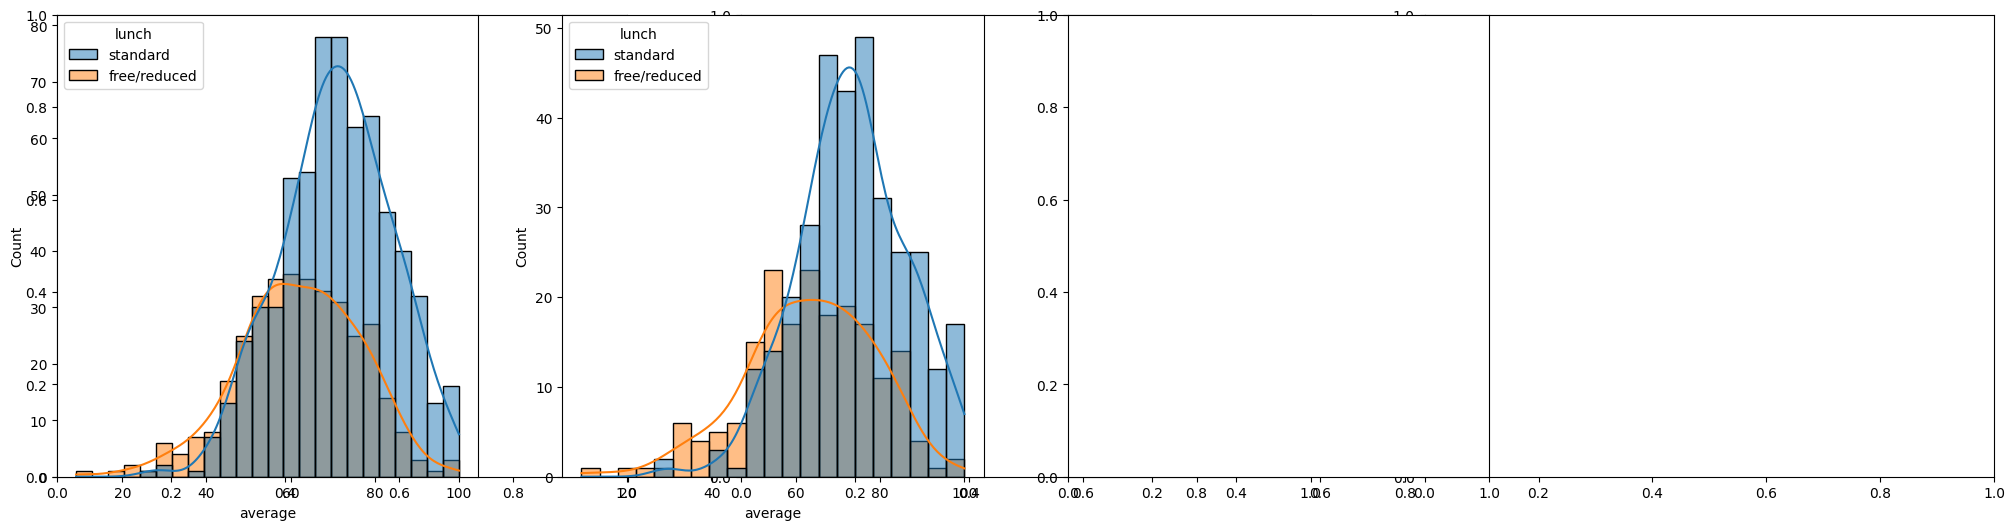

In [20]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average,',kde=True,hue='lunch')
plt.show()